In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
import warnings
warnings.filterwarnings("ignore")
import scipy.cluster.hierarchy as sch

sns.set_theme(style="darkgrid")
plt.style.use("seaborn")

# Season

In [7]:
df_teams= pd.read_csv("../Data/Season.csv")
df_teams.head()

,Team,G,W,L,W/L%,Tm_FG,Tm_FGA,Tm_2P,Tm_2PA,Tm_3P,...,Tm_TOV%,Tm_ORB%,Tm_DRB%,Tm_FTr,Opp_eFG%,Opp_TS%,Opp_TOV%,Opp_ORB%,Opp_DRB%,Opp_FTr
0,WAS,57,10,47,0.175,39.5,89.9,26.6,51.3,12.9,...,14.0,23.0,73.2,0.231,0.552,0.589,11.5,26.8,77.0,0.261
1,UTA,57,14,43,0.246,40.2,87.8,26.3,48.5,14.0,...,15.1,28.0,74.6,0.261,0.555,0.586,10.4,25.4,72.0,0.250
2,TOR,58,18,40,0.310,41.7,89.3,30.1,56.4,11.6,...,13.6,26.2,73.6,0.237,0.546,0.584,12.7,26.4,73.8,0.291
3,SAS,56,24,32,0.429,41.1,89.5,27.3,49.9,13.8,...,12.6,24.2,73.3,0.238,0.538,0.566,11.9,26.7,75.8,0.197
4,SAC,57,29,28,0.509,43.3,91.1,30.8,55.2,12.5,...,11.9,25.3,76.9,0.241,0.549,0.585,12.7,23.1,74.7,0.253


In [8]:
X1= df_teams.drop(columns= ['Team', 'G', 'L', 'W/L%'])

In [9]:
range_n_clusters = list (range(2,9))
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(X1)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X1, preds)
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.2713617799668763)
For n_clusters = 3, silhouette score is 0.2340545219200695)
For n_clusters = 4, silhouette score is 0.18762096563176542)
For n_clusters = 5, silhouette score is 0.19680966844980577)
For n_clusters = 6, silhouette score is 0.18522204784443325)
For n_clusters = 7, silhouette score is 0.1599648280534681)
For n_clusters = 8, silhouette score is 0.14305512335267678)


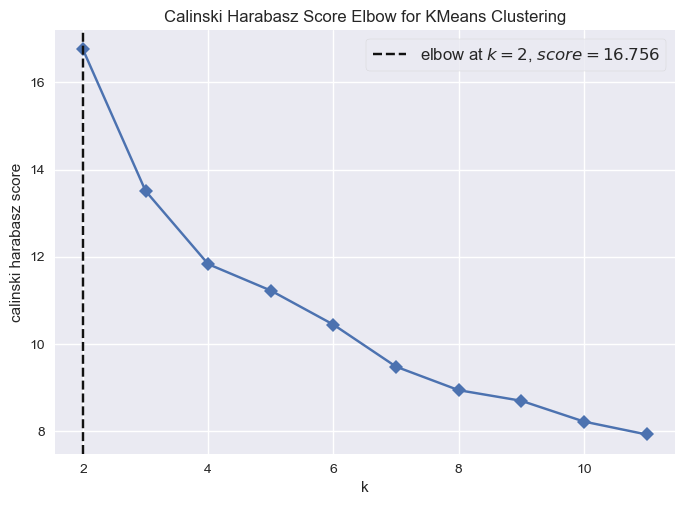

In [10]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,12), metric='calinski_harabasz', timings=False)

visualizer.fit(X1)    
visualizer.poof();

In [16]:
df_teams.columns

Index(['Team', 'G', 'W', 'L', 'W/L%', 'Tm_FG', 'Tm_FGA', 'Tm_2P', 'Tm_2PA',
       'Tm_3P', 'Tm_3PA', 'Tm_FT', 'Tm_FTA', 'Tm_ORB', 'Tm_DRB', 'Tm_TRB',
       'Tm_AST', 'Tm_STL', 'Tm_BLK', 'Tm_TOV', 'Tm_PF', 'Tm_PTS', 'Opp_FG',
       'Opp_FGA', 'Opp_2P', 'Opp_2PA', 'Opp_3P', 'Opp_3PA', 'Opp_FT',
       'Opp_FTA', 'Opp_ORB', 'Opp_DRB', 'Opp_TRB', 'Opp_AST', 'Opp_STL',
       'Opp_BLK', 'Opp_TOV', 'Opp_PF', 'Opp_PTS', 'MOV', 'SOS', 'SRS', 'Pace',
       'ORtg', 'DRtg', 'Tm_eFG%', 'Tm_TS%', 'Tm_TOV%', 'Tm_ORB%', 'Tm_DRB%',
       'Tm_FTr', 'Opp_eFG%', 'Opp_TS%', 'Opp_TOV%', 'Opp_ORB%', 'Opp_DRB%',
       'Opp_FTr'],
      dtype='object')

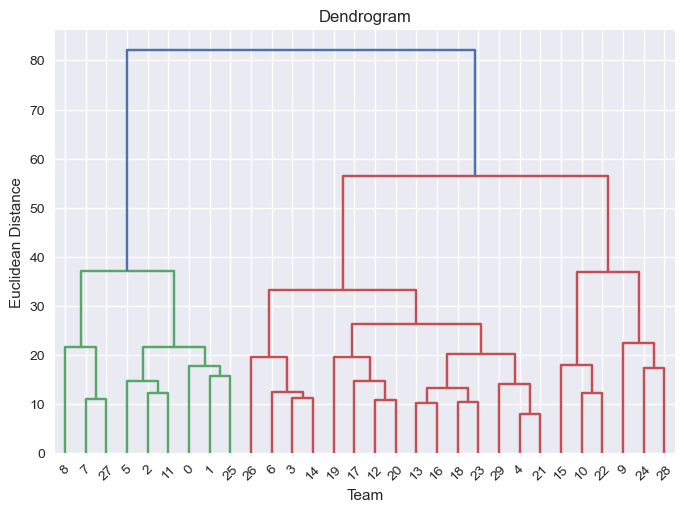

In [28]:
dendrogram = sch.dendrogram(sch.linkage(X1, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Team')
plt.ylabel('Euclidean Distance')
plt.show()

ValueError: Could not interpret value `H/A` for parameter `row`

# Team

In [21]:
X2= df_teams[["Tm_FG", "Tm_FGA", "Tm_2P", "Tm_2PA", "Tm_3P", "Tm_3PA", "Tm_FT", "Tm_FTA", "Tm_ORB", "Tm_AST", "Tm_TOV", 
              "Tm_PTS", "Opp_DRB", "Opp_PF", "ORtg", "Tm_eFG%", "Tm_TS%", "Tm_FTr"]]

In [22]:
range_n_clusters = list (range(2,9))
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(X2)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X2, preds)
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, silhouette score is 0.2727945352933652)
For n_clusters = 3, silhouette score is 0.2793952028512854)
For n_clusters = 4, silhouette score is 0.22624850639768015)
For n_clusters = 5, silhouette score is 0.21360926524960477)
For n_clusters = 6, silhouette score is 0.20981054178630726)
For n_clusters = 7, silhouette score is 0.19963913617942944)
For n_clusters = 8, silhouette score is 0.23392710003897582)


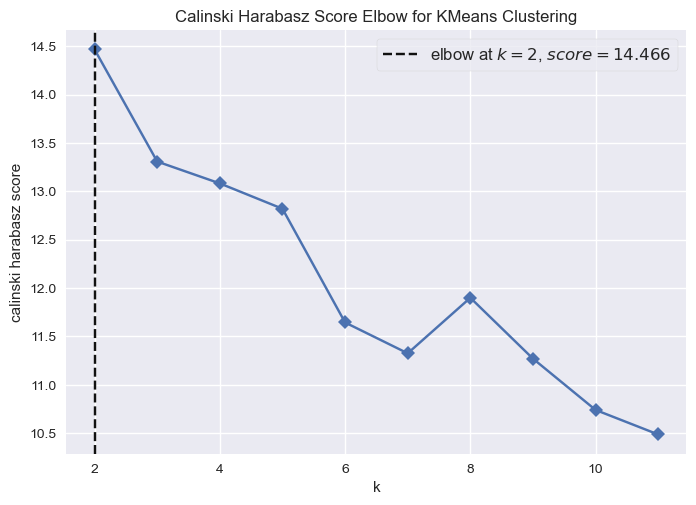

In [23]:
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,12), metric='calinski_harabasz', timings=False)

visualizer.fit(X2)    
visualizer.poof();

# Opponent

For n_clusters = 2, silhouette score is 0.28151001025941635)
For n_clusters = 3, silhouette score is 0.25564267431054344)
For n_clusters = 4, silhouette score is 0.23341514338571664)
For n_clusters = 5, silhouette score is 0.19722858875706786)
For n_clusters = 6, silhouette score is 0.20380312275262277)
For n_clusters = 7, silhouette score is 0.18353526955051933)
For n_clusters = 8, silhouette score is 0.20514310182805193)


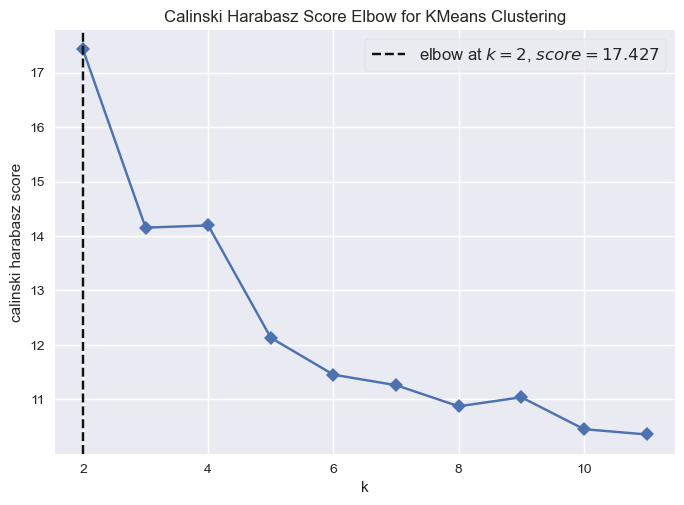

In [25]:
X3= df_teams[["Opp_FG", "Opp_FGA", "Opp_2P", "Opp_2PA", "Opp_3P", "Opp_3PA", "Opp_FT", "Opp_FTA", "Opp_ORB", "Opp_AST", "Opp_TOV", 
              "Opp_PTS", "Tm_DRB", "Tm_PF", "DRtg", "Opp_eFG%", "Opp_TS%", "Opp_FTr"]]
range_n_clusters = list (range(2,9))
for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict(X3)
    centers = clusterer.cluster_centers_

    score = silhouette_score(X3, preds)
    print("For n_clusters = {}, silhouette score is {})".format(n_clusters, score))
model = KMeans()
visualizer = KElbowVisualizer(model, k=(2,12), metric='calinski_harabasz', timings=False)

visualizer.fit(X3)    
visualizer.poof();

In [31]:
df_teams.describe()

,G,W,L,W/L%,Tm_FG,Tm_FGA,Tm_2P,Tm_2PA,Tm_3P,Tm_3PA,...,Tm_TOV%,Tm_ORB%,Tm_DRB%,Tm_FTr,Opp_eFG%,Opp_TS%,Opp_TOV%,Opp_ORB%,Opp_DRB%,Opp_FTr
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,...,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,57.533333,28.766667,28.766667,0.499767,41.460000,89.180000,28.040000,51.686667,13.436667,37.506667,...,12.783333,25.080000,74.890000,0.245033,0.540233,0.574000,12.800000,25.110000,74.920000,0.245200
std,0.937102,9.364951,9.279876,0.162133,2.125153,2.342471,2.309889,3.623937,1.481491,3.383931,...,1.028586,2.559014,1.518245,0.016029,0.013185,0.013178,1.275228,1.518245,2.559014,0.025207
min,56.000000,10.000000,10.000000,0.175000,37.500000,85.300000,24.000000,42.100000,10.800000,31.400000,...,10.500000,19.500000,72.200000,0.209000,0.506000,0.547000,10.400000,21.900000,68.900000,0.197000
25%,57.000000,23.250000,22.500000,0.405000,40.200000,87.025000,26.525000,49.325000,12.500000,35.425000,...,12.075000,23.300000,73.625000,0.234750,0.531250,0.563750,11.900000,23.925000,73.650000,0.230250
50%,58.000000,30.000000,28.000000,0.517000,41.400000,89.400000,28.000000,51.050000,13.150000,37.400000,...,12.600000,25.350000,74.900000,0.247000,0.540500,0.574500,12.700000,25.100000,74.650000,0.248000
75%,58.000000,34.250000,34.500000,0.608500,42.500000,90.475000,29.400000,54.400000,14.075000,39.200000,...,13.575000,26.350000,76.075000,0.257750,0.548750,0.583750,13.350000,26.375000,76.700000,0.259250
max,60.000000,48.000000,47.000000,0.828000,45.800000,93.400000,33.800000,58.600000,17.800000,48.400000,...,15.100000,31.100000,78.100000,0.270000,0.568000,0.602000,15.700000,27.800000,80.500000,0.292000


# Games

In [35]:
df_sh= pd.read_csv("../Data/Shooting.csv")
df_sh.drop(columns=['MP'], inplace= True)
cols_to_delete= ["Rk"]
df_sh["Date"] = pd.to_datetime(df_sh["Date"], format="%Y-%m-%d")
df_sh = df_sh.drop(columns= cols_to_delete)
df_sh["H/A"] = df_sh["H/A"].fillna("H").replace("@", "A")
df3["Result"] = df3["Result"].str[0]
df_sh.head()

,Rk,Team,Date,H/A,Opp,Result,Tm_FG,Tm_FGA,Tm_FG%,Tm_2P,...,Opp_2P,Opp_2PA,Opp_2P%,Opp_3P,Opp_3PA,Opp_3P%,Opp_FT,Opp_FTA,Opp_FT%,Opp_PTS
0,1,DEN,2025-02-10,NaN,POR,"W, 146-117",60,91,0.659,52,...,25,51,0.490,15,37,0.405,22,26,0.846,117
1,2,MEM,2024-12-26,NaN,TOR,"W, 155-126",58,109,0.532,40,...,35,65,0.538,14,43,0.326,14,18,0.778,126
2,3,SAS,2025-01-23,@,IND,"W, 140-110",58,96,0.604,40,...,31,54,0.574,13,43,0.302,9,12,0.750,110
3,4,DEN,2025-02-05,NaN,NOP,"W, 144-119",57,100,0.570,41,...,33,64,0.516,10,29,0.345,23,26,0.885,119
4,5,OKC,2025-02-01,NaN,SAC,"W, 144-110",57,107,0.533,38,...,29,56,0.518,11,44,0.250,19,26,0.731,110


In [ ]:
g = sns.displot(
    X1, x="Tm_PTS", col="Team", row="H/A",
    binwidth=3, height=3, facet_kws=dict(margin_titles=True))
g.fig.set_size_inches(18, 10)
g.set_axis_labels("Total Bill", "Frequency")

In [40]:
import pandas as pd

# Example dataset: Game-by-game data for a team
data = pd.DataFrame({
    'team': ['LAL', 'LAL', 'LAL', 'LAL', 'LAL', 'LAL', 'LAL'],
    'date': pd.to_datetime(['2024-01-01', '2024-01-03', '2024-01-06', 
                            '2024-01-08', '2024-01-10', '2024-01-12', '2024-01-15']),
    'points': [110, 102, 115, 98, 120, 108, 99],
    'pace': [98, 101, 96, 99, 100, 97, 102],
})

# Sort by team and date
data = data.sort_values(by=['team', 'date'])

# Create Lagged Features (points in the last 3 games)
for lag in [1, 2, 3]:  
    data[f'points_lag_{lag}'] = data.groupby('team')['points'].shift(lag)

# Create Rolling Average Features (last 3 games)
data['points_rolling_avg_3'] = data.groupby('team')['points'].shift(1).rolling(window=3).mean()

# Create Rolling Standard Deviation (variance measure)
data['points_rolling_std_3'] = data.groupby('team')['points'].shift(1).rolling(window=3).std()

# Create Lagged Pace (last 3 games)
for lag in [1, 2, 3]:  
    data[f'pace_lag_{lag}'] = data.groupby('team')['pace'].shift(lag)

# Fill NA values (only after shifting to avoid data leakage)
data = data.fillna(0)

# Show the dataframe
data


,team,date,points,pace,points_lag_1,points_lag_2,points_lag_3,points_rolling_avg_3,points_rolling_std_3,pace_lag_1,pace_lag_2,pace_lag_3
0,LAL,2024-01-01,110,98,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0
1,LAL,2024-01-03,102,101,110.0,0.0,0.0,0.000000,0.000000,98.0,0.0,0.0
2,LAL,2024-01-06,115,96,102.0,110.0,0.0,0.000000,0.000000,101.0,98.0,0.0
3,LAL,2024-01-08,98,99,115.0,102.0,110.0,109.000000,6.557439,96.0,101.0,98.0
4,LAL,2024-01-10,120,100,98.0,115.0,102.0,105.000000,8.888194,99.0,96.0,101.0
5,LAL,2024-01-12,108,97,120.0,98.0,115.0,111.000000,11.532563,100.0,99.0,96.0
6,LAL,2024-01-15,99,102,108.0,120.0,98.0,108.666667,11.015141,97.0,100.0,99.0
